In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import StandardScaler , OneHotEncoder , LabelEncoder 
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

import shap



In [4]:
df = pd.read_csv("C:/Users/Ritisha Bagchi/Downloads/german_credit_data (1).csv")
df.head()
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
df.shape
df.info()
df.isnull().sum()
df.describe()
df['Risk'].value_counts()
df['Risk'].value_counts(normalize=True) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


Risk
good    0.7
bad     0.3
Name: proportion, dtype: float64

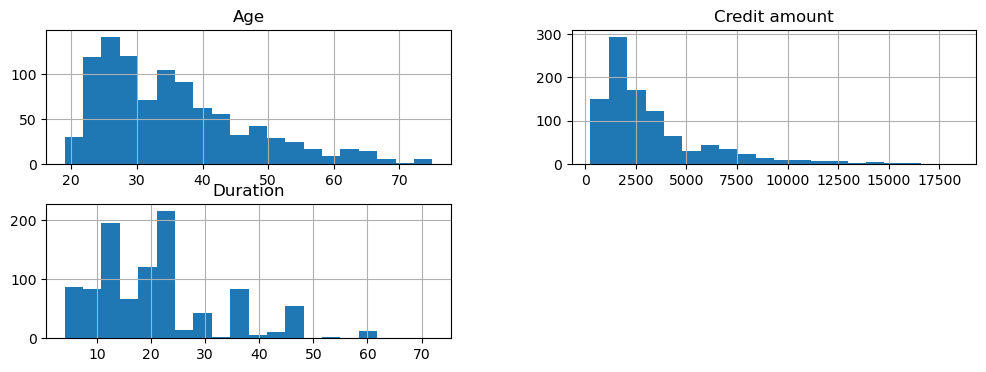

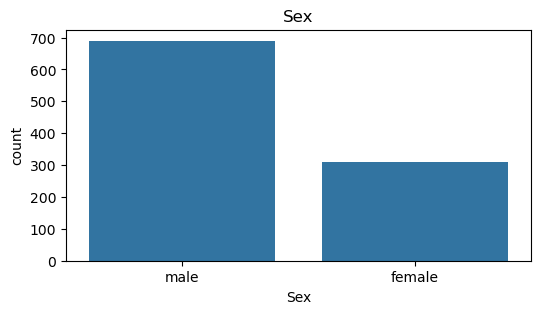

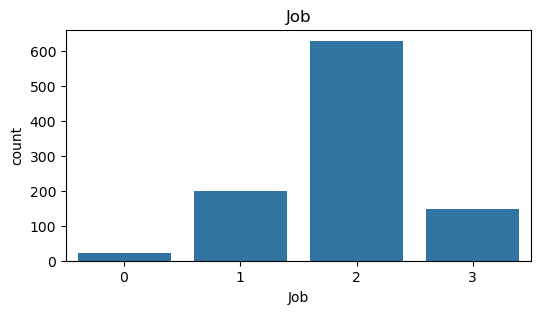

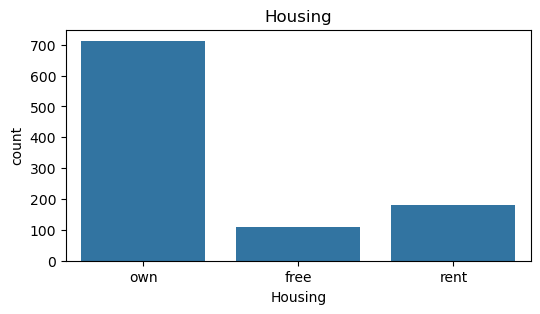

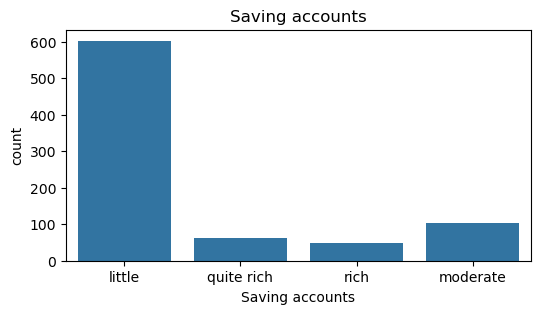

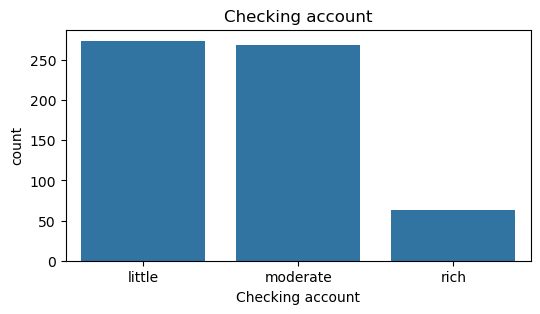

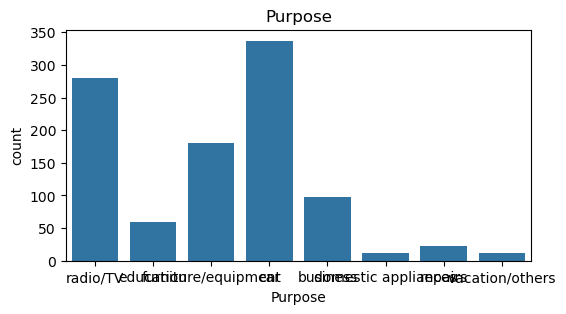

In [5]:

df[['Age', 'Credit amount', 'Duration']].hist(figsize=(12,4), bins=20)
plt.show()


for col in ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.show()

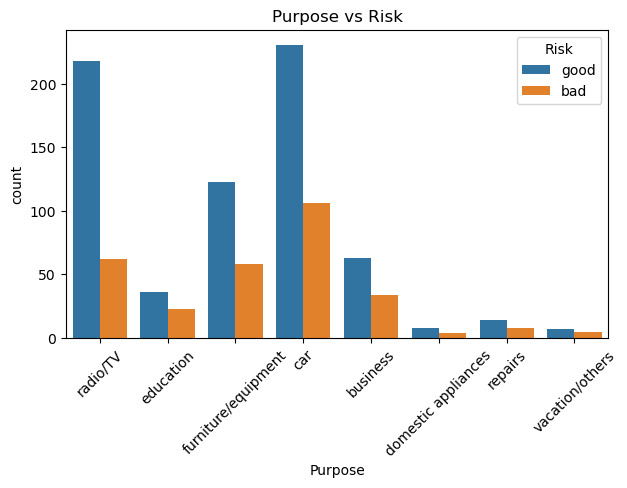

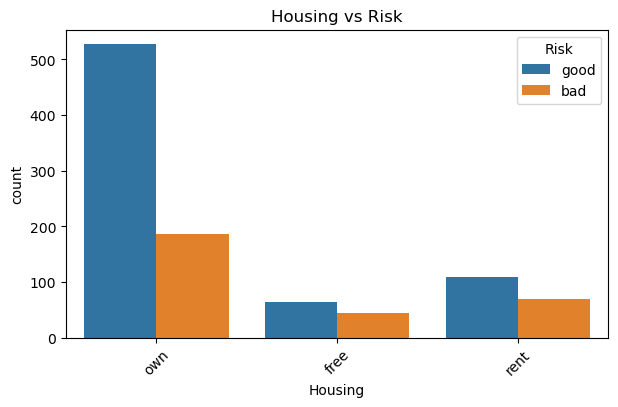

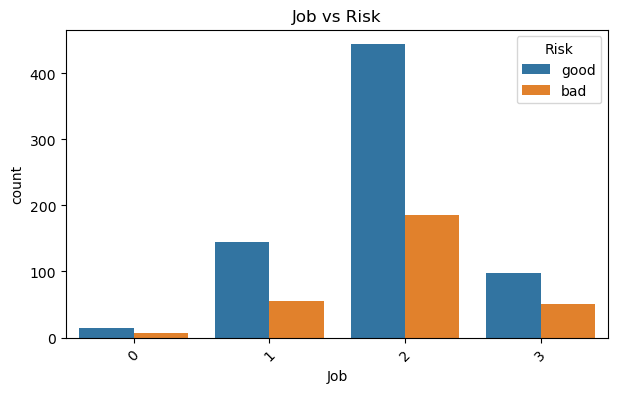

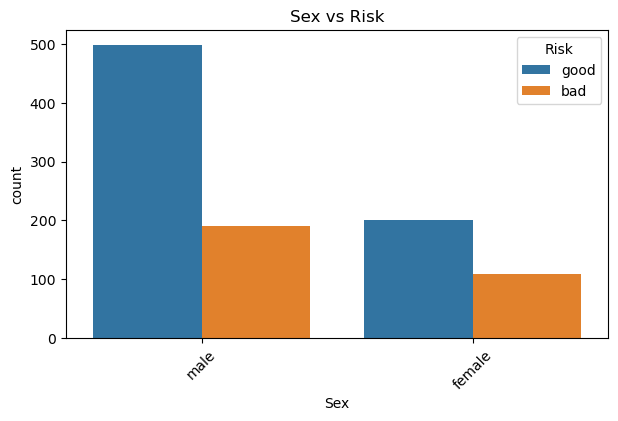

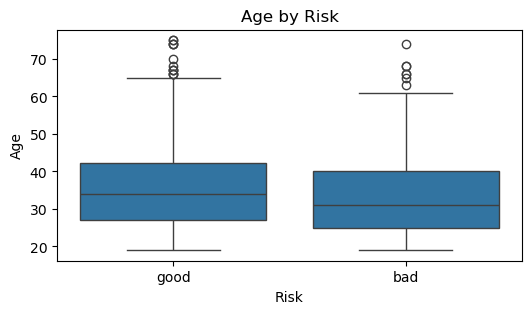

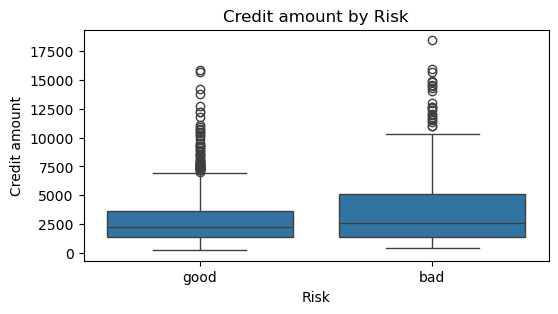

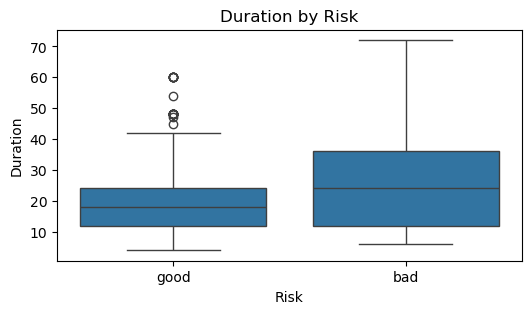

In [6]:

for col in ['Purpose', 'Housing', 'Job', 'Sex']:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, hue='Risk', data=df)
    plt.title(f'{col} vs Risk')
    plt.xticks(rotation=45)
    plt.show()

# Numeric vs target
for col in ['Age', 'Credit amount', 'Duration']:
    plt.figure(figsize=(6,3))
    sns.boxplot(x='Risk', y=col, data=df)
    plt.title(f'{col} by Risk')
    plt.show()

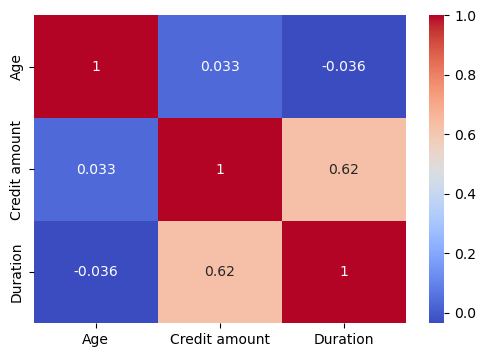

In [7]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Age','Credit amount','Duration']].corr(), annot=True, cmap='coolwarm')
plt.show()

In [8]:
df['Saving accounts'] = df['Saving accounts'].fillna('none')
df['Checking account'] = df['Checking account'].fillna('none')
df['Credit amount'] = np.log(df['Credit amount'])
df['Age_cat'] = pd.cut(df['Age'], bins=[18, 25, 35, 60, 120], labels=['Student', 'Young', 'Adult', 'Senior'])
df['Amount_per_duration'] = df['Credit amount'] / df['Duration']


In [9]:
df['Age_cat'] = pd.cut(df['Age'], bins=[18, 25, 35, 60, 120], labels=['Student', 'Young', 'Adult', 'Senior'])
df['Amount_per_duration'] = df['Credit amount'] / df['Duration']

In [10]:
df['Risk'] = df['Risk'].map({'good': 0, 'bad': 1})
df = pd.get_dummies(df, columns=['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Age_cat'], drop_first=True)

In [11]:
df['Risk'].unique()
df['Risk'].isnull().sum()

np.int64(0)

In [12]:
X = df.drop('Risk', axis=1)
y = df['Risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

In [13]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train_bal, y_train_bal)
y_pred = lr.predict(X_test_scaled)

In [14]:
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]))

              precision    recall  f1-score   support

           0       0.83      0.73      0.78       140
           1       0.51      0.65      0.57        60

    accuracy                           0.70       200
   macro avg       0.67      0.69      0.67       200
weighted avg       0.73      0.70      0.71       200

AUC: 0.7277380952380953


In [15]:
import pickle
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(X.columns.tolist(), open('columns.pkl', 'wb'))

In [16]:
xgb = XGBClassifier(max_depth=4, learning_rate=0.1, n_estimators=150, random_state=42, eval_metric='logloss')
xgb.fit(X_train_bal, y_train_bal)
y_pred_xgb = xgb.predict(X_test_scaled)

In [17]:
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]))

print("\n=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test_scaled)[:,1]))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.83      0.73      0.78       140
           1       0.51      0.65      0.57        60

    accuracy                           0.70       200
   macro avg       0.67      0.69      0.67       200
weighted avg       0.73      0.70      0.71       200

AUC: 0.7277380952380953

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       140
           1       0.55      0.60      0.58        60

    accuracy                           0.73       200
   macro avg       0.69      0.70      0.69       200
weighted avg       0.74      0.73      0.74       200

AUC: 0.7623809523809523


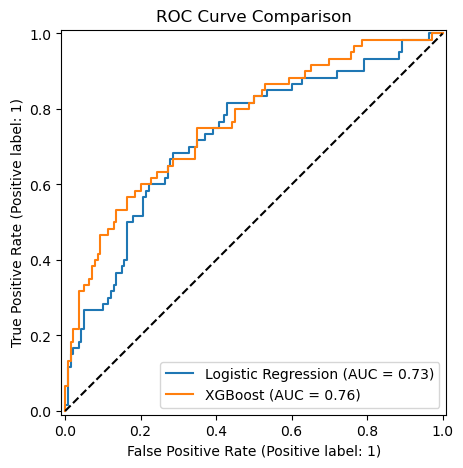

In [18]:
from sklearn.metrics import RocCurveDisplay
fig, ax = plt.subplots(figsize=(6,5))
RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(xgb, X_test_scaled, y_test, ax=ax, name='XGBoost')
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve Comparison")
plt.show()

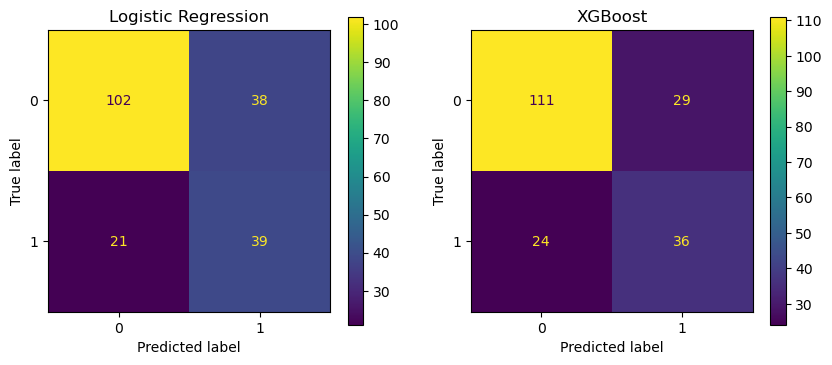

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(10,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0])
axes[0].set_title("Logistic Regression")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, ax=axes[1])
axes[1].set_title("XGBoost")
plt.show()

In [ ]:
#While XGBoost achieved a higher AUC (0.76 vs 0.73), Logistic Regression demonstrated higher recall on defaulters (65% vs 60%), 
# correctly identifying 39 of 60 actual defaulters compared to XGBoost's 36. Given that in credit risk, the cost of missing a defaulter (false negative) 
# typically outweighs the cost of rejecting a creditworthy applicant (false positive), Logistic Regression's higher recall makes it the 
# more business-appropriate choice for this use case — despite XGBoost's stronger overall discriminative performance."


In [24]:
explainer = shap.LinearExplainer(lr, X_train_scaled)
def predict_risk(age, sex, job, housing, saving, checking, credit_amount, duration, purpose, explain=True):
    # Build raw input
    new_data = pd.DataFrame({
        'Age': [age], 'Sex': [sex], 'Job': [job], 'Housing': [housing],
        'Saving accounts': [saving], 'Checking account': [checking],
        'Credit amount': [credit_amount], 'Duration': [duration], 'Purpose': [purpose]
    })
    
    # Same preprocessing as training
    new_data['Credit amount'] = np.log(new_data['Credit amount'])
    new_data['Age_cat'] = pd.cut(new_data['Age'], bins=[18,25,35,60,120], labels=['Student','Young','Adult','Senior'])
    new_data['Amount_per_duration'] = new_data['Credit amount'] / new_data['Duration']
    new_data = pd.get_dummies(new_data, columns=['Sex','Housing','Saving accounts','Checking account','Purpose','Age_cat'])
    
    # Match training columns exactly
    new_data = new_data.reindex(columns=X.columns, fill_value=0)
    
    # Scale
    new_data_scaled = scaler.transform(new_data)
    
    # Predict
    pred = lr.predict(new_data_scaled)[0]
    prob = lr.predict_proba(new_data_scaled)[0][1]
    
    result = "Bad Risk (likely default)" if pred == 1 else "Good Risk"
    print(f"Prediction: {result}")
    print(f"Probability of default: {prob:.1%}")
    
    if explain:
        shap_values = explainer.shap_values(new_data_scaled)
        
        # Top contributing features for this specific prediction
        contributions = pd.DataFrame({
            'feature': X.columns,
            'shap_value': shap_values[0]
        }).sort_values('shap_value', key=abs, ascending=False)
        
        print("\nTop factors influencing this prediction:")
        for _, row in contributions.head(5).iterrows():
            direction = "↑ increases risk" if row['shap_value'] > 0 else "↓ decreases risk"
            print(f"  {row['feature']}: {direction} ({row['shap_value']:.3f})")
        
        # Visual force plot
        shap.force_plot(explainer.expected_value, shap_values[0], new_data, matplotlib=True)
    
    return pred, prob

Prediction: Bad Risk (likely default)
Probability of default: 76.8%

Top factors influencing this prediction:
  Checking account_none: ↑ increases risk (0.859)
  Amount_per_duration: ↑ increases risk (0.574)
  Checking account_moderate: ↓ decreases risk (-0.421)
  Housing_rent: ↑ increases risk (0.267)
  Age_cat_Adult: ↑ increases risk (0.246)


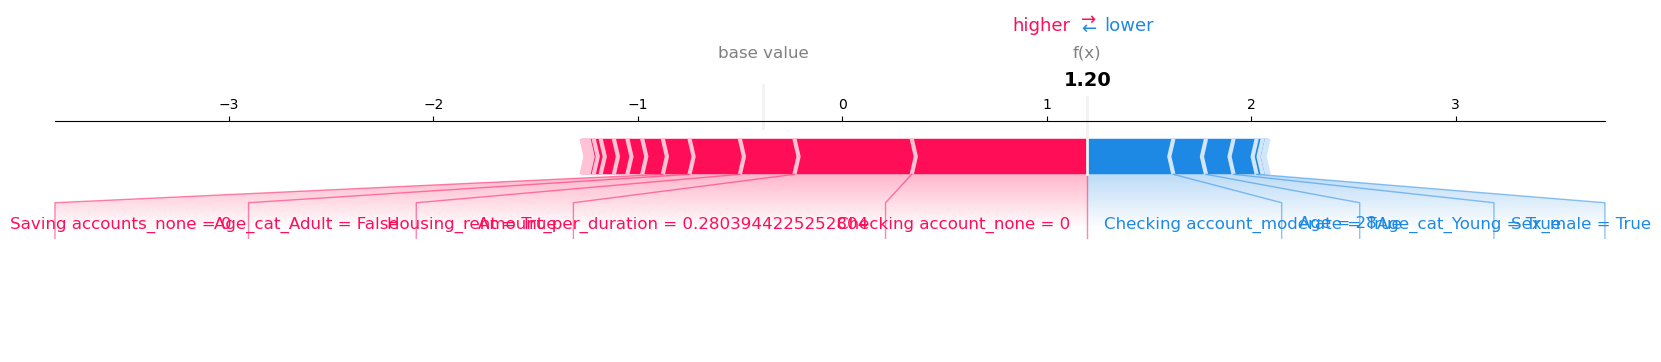

(np.int64(1), np.float64(0.7682734085277205))

In [25]:
#testing the model 
predict_risk(
    age=28, sex='male', job=2, housing='rent',
    saving='little', checking='moderate',
    credit_amount=4500, duration=30, purpose='car'
)

Prediction: Good Risk
Probability of default: 18.3%

Top factors influencing this prediction:
  Saving accounts_rich: ↓ decreases risk (-1.550)
  Checking account_none: ↑ increases risk (0.859)
  Checking account_rich: ↓ decreases risk (-0.554)
  Age_cat_Adult: ↓ decreases risk (-0.402)
  Sex_male: ↑ increases risk (0.252)


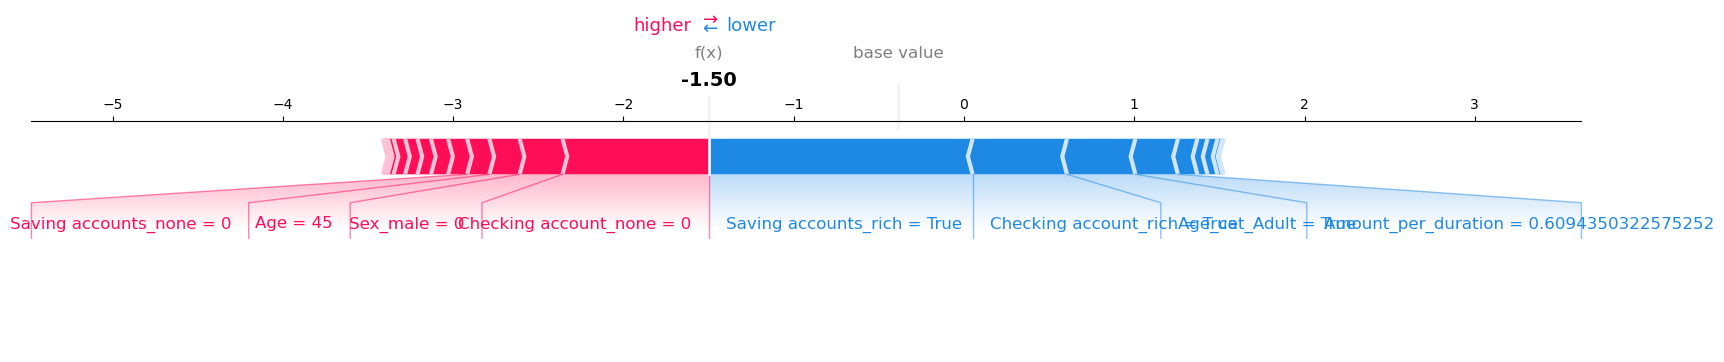

(np.int64(0), np.float64(0.18257193408004255))

In [26]:
predict_risk(
    age=45, sex='female', job=3, housing='own',
    saving='rich', checking='rich',
    credit_amount=1500, duration=12, purpose='furniture/equipment'
)

In [27]:
import pickle
pickle.dump(lr, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(X.columns.tolist(), open('columns.pkl', 'wb'))